# Multicollinearity Analysis — `factory_cleaned.csv`

**Objective**: Identify and resolve multicollinearity among the 19 numerical features to improve linear model stability and feature selection.

**Findings from EDA (notebook 02)**:
- `Remaining_Lease_Years` and `Lease_Duration` are highly correlated (r=0.813)
- `Postal District` and `Postal Sector` excluded — numerical codes, not true continuous variables
- 19 macro features are low-cardinality aggregates — high intercorrelation risk
- `Year`, `Month`, `Quarter` excluded — mapping keys only

---

## Contents
1. Imports & Data Loading
2. Pearson Correlation Heatmap
3. High-Correlation Pair Extraction
4. VIF Analysis — All 19 Features
5. Sub-Group Deep Dives
   - 5a. Lease Group
   - 5b. Location Features — Excluded
   - 5c. Macro Group
   - 5d. Time Features — Excluded
6. Iterative VIF Reduction
7. Summary & Recommendations

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/factory_cleaned.csv")

TARGET = "Unit Price ($ psf)"

# NOTE: Year, Month, Quarter are excluded — mapping keys used solely to join
# macro indicators onto transactions, not predictive features.
# NOTE: Postal District and Postal Sector are excluded — they are numerical
# codes (identifiers), not true continuous variables. The observed correlation
# with price is a coincidence of how Singapore postal districts are numbered.
# Location is better captured by Region and Planning Area (proper categoricals).
FEATURE_COLS = [
    "Area (sqft)",
    "Lease_Duration", "Remaining_Lease_Years",
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "Price_Index",
    "5Y_Bond_Yield", "2Y_Bond_Yield", "10Y_Bond_Yield", "1Y_TBills",
    "15Y_Bond_Yield", "20Y_Bond_Yield",
    "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne",
    "Ready_Mixed_Concrete_Per_m3",
]

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET}")
print(f"\nExcluded (mapping keys only): Year, Month, Quarter")
print(f"Excluded (numerical codes, not continuous): Postal District, Postal Sector")
print(f"Null counts in features: {df[FEATURE_COLS].isnull().sum().sum()} (total)")

Dataset shape: (3789, 32)
Features: 19
Target: Unit Price ($ psf)

Excluded (mapping keys only): Year, Month, Quarter
Excluded (numerical codes, not continuous): Postal District, Postal Sector
Null counts in features: 0 (total)


## 2. Pearson Correlation Heatmap

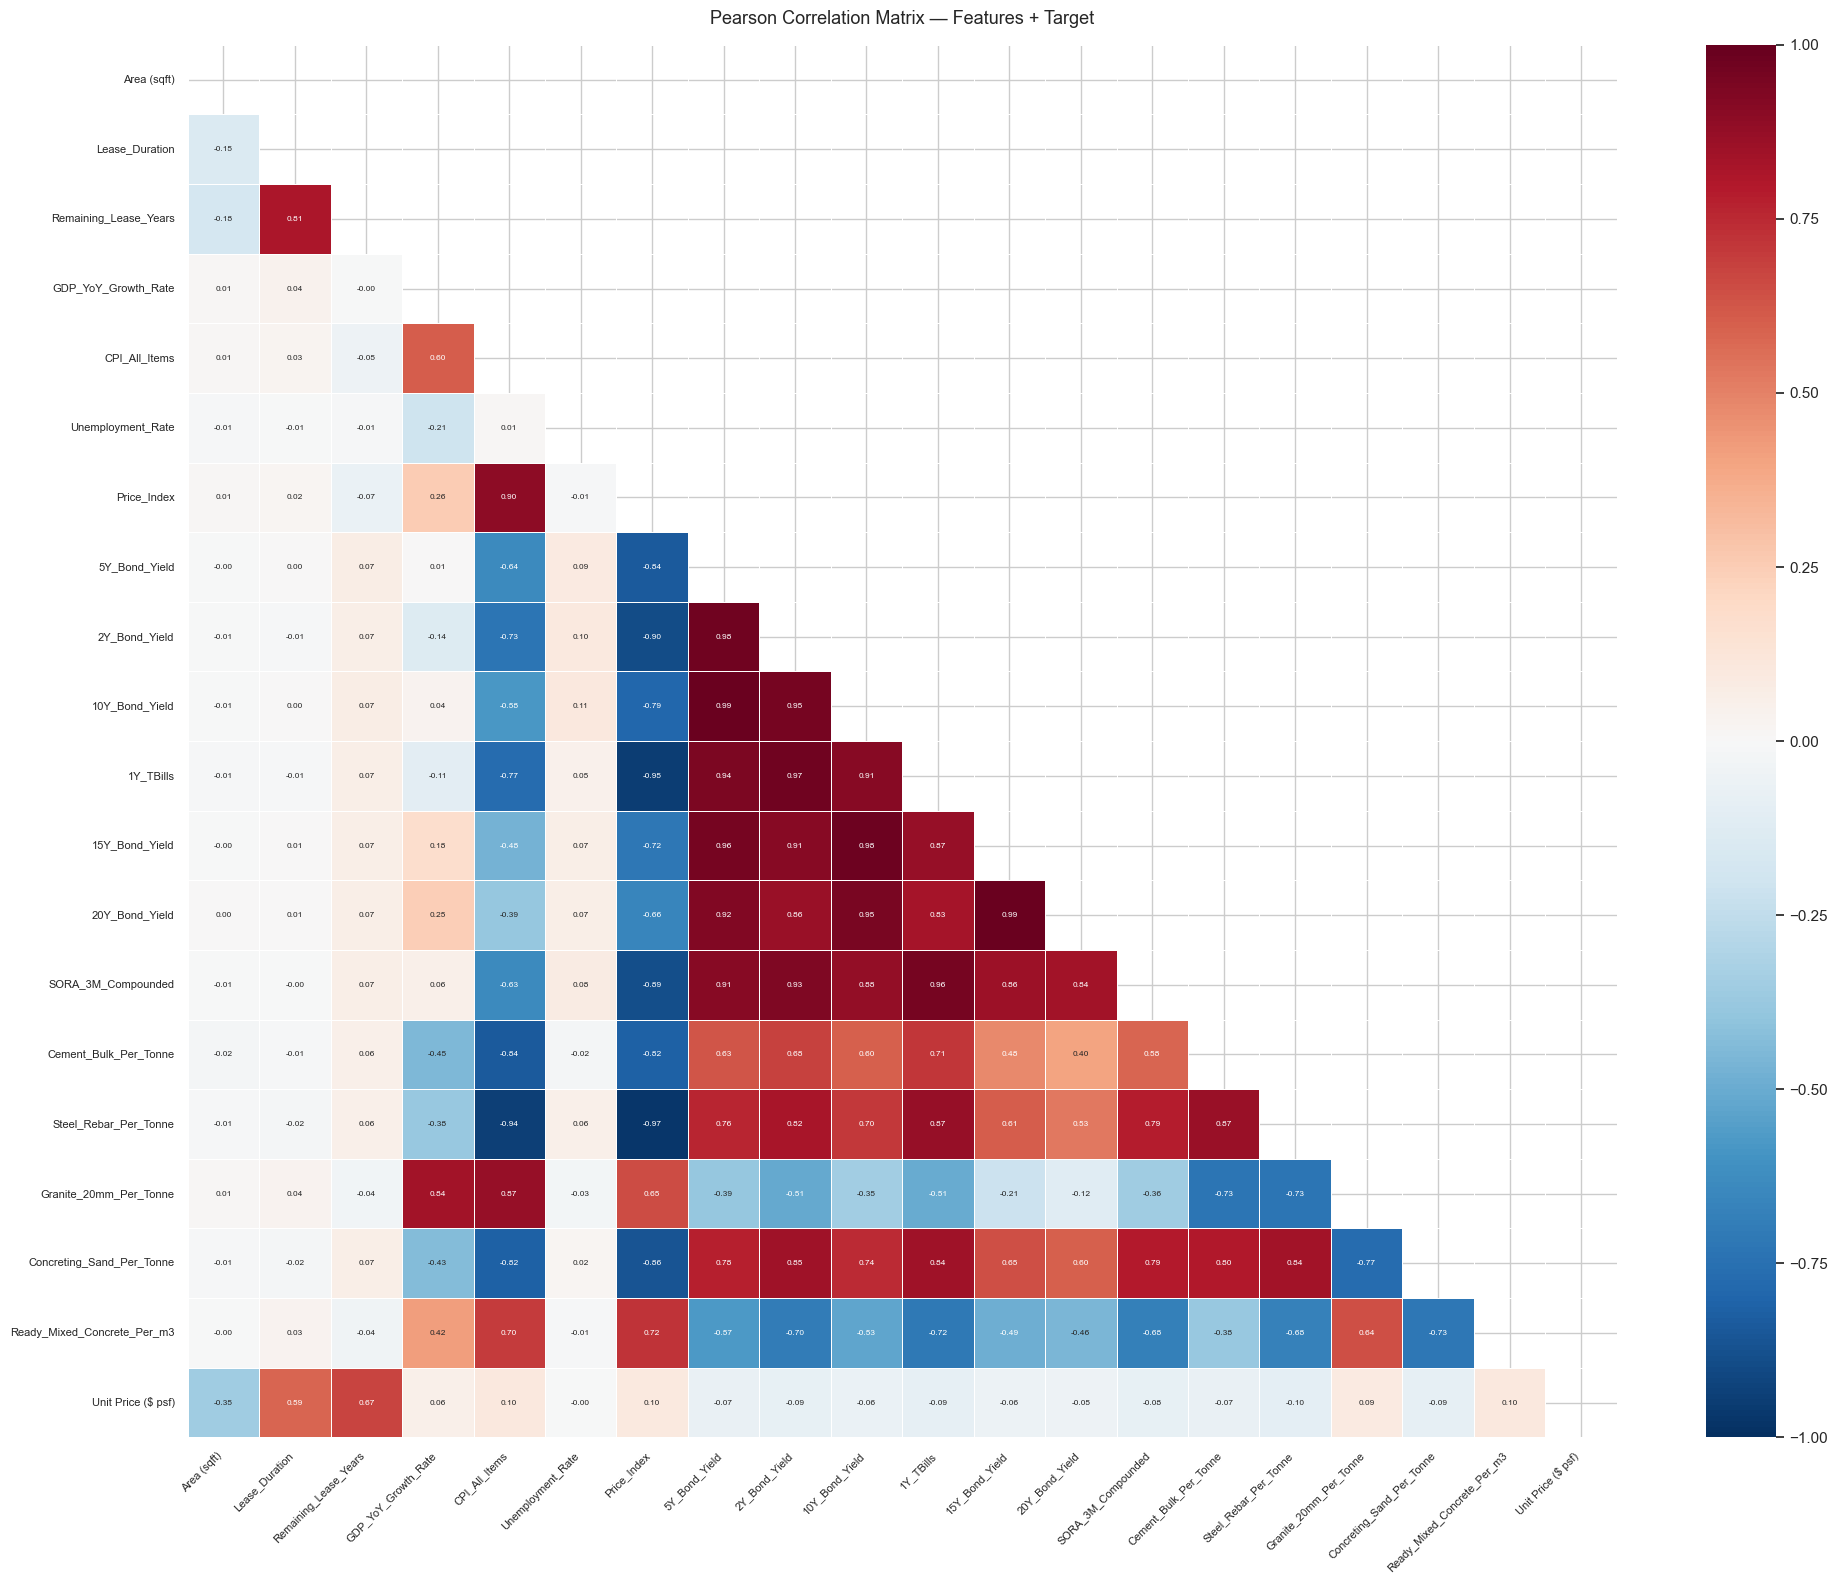

In [2]:
corr = df[FEATURE_COLS + [TARGET]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    annot_kws={"size": 6}, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Features + Target", fontsize=13, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 3. High-Correlation Pair Extraction

In [3]:
feature_corr = df[FEATURE_COLS].corr()

# Extract upper triangle pairs only (exclude self-correlations)
pairs = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        r = feature_corr.iloc[i, j]
        pairs.append({"Feature_1": FEATURE_COLS[i], "Feature_2": FEATURE_COLS[j], "Correlation": round(r, 3)})

pairs_df = pd.DataFrame(pairs).sort_values("Correlation", key=abs, ascending=False)

print("=== ACTION REQUIRED: |r| > 0.80 ===")
high = pairs_df[pairs_df["Correlation"].abs() > 0.80]
display(high.reset_index(drop=True))

print(f"\n=== WATCH LIST: 0.70 < |r| ≤ 0.80 ===")
watch = pairs_df[(pairs_df["Correlation"].abs() > 0.70) & (pairs_df["Correlation"].abs() <= 0.80)]
display(watch.reset_index(drop=True))

=== ACTION REQUIRED: |r| > 0.80 ===


,Feature_1,Feature_2,Correlation
0,5Y_Bond_Yield,10Y_Bond_Yield,0.989
1,15Y_Bond_Yield,20Y_Bond_Yield,0.989
2,10Y_Bond_Yield,15Y_Bond_Yield,0.981
3,5Y_Bond_Yield,2Y_Bond_Yield,0.975
4,2Y_Bond_Yield,1Y_TBills,0.972
5,Price_Index,Steel_Rebar_Per_Tonne,-0.971
6,5Y_Bond_Yield,15Y_Bond_Yield,0.960
7,1Y_TBills,SORA_3M_Compounded,0.959
8,2Y_Bond_Yield,10Y_Bond_Yield,0.954
9,10Y_Bond_Yield,20Y_Bond_Yield,0.952



=== WATCH LIST: 0.70 < |r| ≤ 0.80 ===


,Feature_1,Feature_2,Correlation
0,Price_Index,10Y_Bond_Yield,-0.793
1,SORA_3M_Compounded,Concreting_Sand_Per_Tonne,0.790
2,SORA_3M_Compounded,Steel_Rebar_Per_Tonne,0.788
3,5Y_Bond_Yield,Concreting_Sand_Per_Tonne,0.779
4,Granite_20mm_Per_Tonne,Concreting_Sand_Per_Tonne,-0.769
5,CPI_All_Items,1Y_TBills,-0.767
6,5Y_Bond_Yield,Steel_Rebar_Per_Tonne,0.760
7,10Y_Bond_Yield,Concreting_Sand_Per_Tonne,0.743
8,Cement_Bulk_Per_Tonne,Granite_20mm_Per_Tonne,-0.734
9,Steel_Rebar_Per_Tonne,Granite_20mm_Per_Tonne,-0.731


### Key Findings

The **41** high-correlation pairs (|r| > 0.80) fall into **four** clear groups:

**Group 1 — Interest Rate Cluster (bond yields + SORA)**  
All 6 bond yield features (5Y, 2Y, 10Y, 1Y_TBills, 15Y, 20Y) and SORA are measuring the same underlying variable: the interest rate environment. Pairwise correlations are 0.83–0.99. Only one representative needs to be kept.

---

**Group 2 — Price Index vs Interest Rates (anti-correlated)**  
`Price_Index` is strongly negatively correlated with bond yields (r = −0.84 to −0.95) and SORA (r = −0.89). As interest rates rose post-2022, property price indices fell — they are capturing the same macro cycle from opposite directions.

---

**Group 3 — Construction Materials Cluster**  
`Cement_Bulk_Per_Tonne`, `Steel_Rebar_Per_Tonne`, and `Concreting_Sand_Per_Tonne` are intercorrelated (r = 0.80–0.87). Also correlated with bond yields (r = 0.71–0.88) and anti-correlated with `CPI_All_Items` (r = −0.82 to −0.94). Materials prices are largely driven by the same macro cycle.

---

**Group 4 — Lease Group**  
`Lease_Duration` vs `Remaining_Lease_Years` (r = 0.814) — identified in notebook 02. One must be dropped; `Remaining_Lease_Years` has the stronger target correlation (r = +0.674 vs +0.585).

---

**Implication**: Most of the 19 features are redundant. Domain-knowledge-driven feature selection in Section 6 will determine which representative to keep from each group.

## 4. VIF Analysis — All 19 Features

VIF measures how much variance of a coefficient is inflated due to collinearity with other features.  

| VIF | Interpretation |
|-----|---------------|
| < 5 | OK — low collinearity |
| 5–10 | WATCH — moderate collinearity |
| > 10 | HIGH — problematic, consider removing |  

---
>
> **Note**: `Year`, `Month`, `Quarter` are excluded — mapping keys only, not model features.
> `Postal District` and `Postal Sector` are excluded — numerical codes, not true continuous variables. Location is captured by `Region` and `Planning Area` (categorical features).

In [4]:
def compute_vif(feature_df):
    """Compute VIF for each feature in the DataFrame after standardising."""
    X = StandardScaler().fit_transform(feature_df)
    vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    result = pd.DataFrame({
        "Feature": feature_df.columns,
        "VIF": np.round(vif_vals, 2)
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    result["Flag"] = result["VIF"].apply(
        lambda v: "HIGH" if v > 10 else ("WATCH" if v > 5 else "OK")
    )
    return result

# Colour-coded display
def highlight_vif(row):
    if row["Flag"] == "HIGH":
        return ["background-color: #c0392b; color: white; font-weight: bold"] * len(row)
    elif row["Flag"] == "WATCH":
        return ["background-color: #e67e22; color: white; font-weight: bold"] * len(row)
    return ["background-color: #27ae60; color: white"] * len(row)

In [5]:
vif_all = compute_vif(df[FEATURE_COLS].dropna())
print(f"VIF Analysis — {len(FEATURE_COLS)} features")
vif_all.style.apply(highlight_vif, axis=1)

VIF Analysis — 19 features


,Feature,VIF,Flag
0,15Y_Bond_Yield,719.700000,HIGH
1,10Y_Bond_Yield,327.030000,HIGH
2,5Y_Bond_Yield,295.530000,HIGH
3,20Y_Bond_Yield,256.870000,HIGH
4,2Y_Bond_Yield,226.060000,HIGH
5,Price_Index,117.960000,HIGH
6,1Y_TBills,93.530000,HIGH
7,CPI_All_Items,91.810000,HIGH
8,Steel_Rebar_Per_Tonne,83.890000,HIGH
9,SORA_3M_Compounded,62.800000,HIGH


## 5. Sub-Group Deep Dives

### 5a. Lease Group — `Lease_Duration` vs `Remaining_Lease_Years`

Lease_Duration vs Remaining_Lease_Years:  r = 0.814
Lease_Duration vs Unit Price ($ psf):     r = 0.585
Remaining_Lease_Years vs Unit Price ($ psf): r = 0.674

Recommendation: Keep Remaining_Lease_Years (higher target correlation: 0.674 vs 0.585)


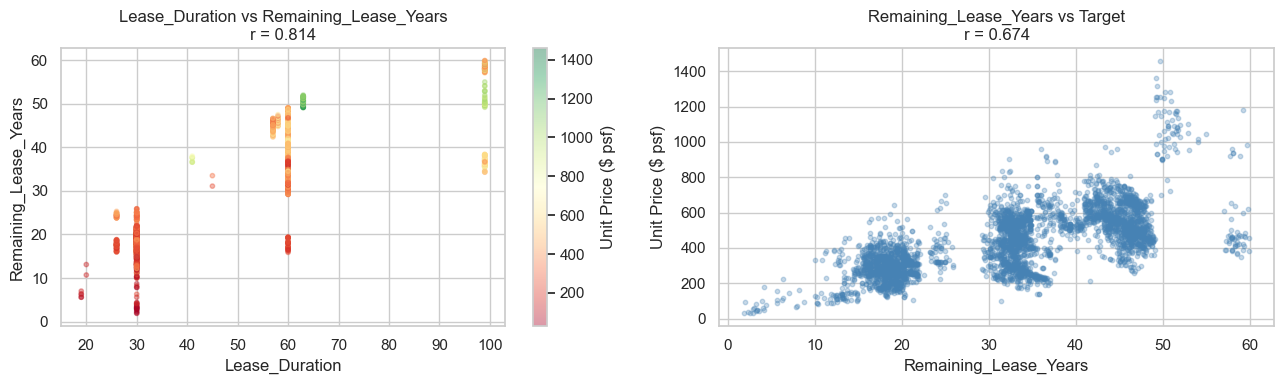

In [6]:
r_lease = df["Lease_Duration"].corr(df["Remaining_Lease_Years"])
r_ld_target = df["Lease_Duration"].corr(df[TARGET])
r_rl_target = df["Remaining_Lease_Years"].corr(df[TARGET])

print(f"Lease_Duration vs Remaining_Lease_Years:  r = {r_lease:.3f}")
print(f"Lease_Duration vs {TARGET}:     r = {r_ld_target:.3f}")
print(f"Remaining_Lease_Years vs {TARGET}: r = {r_rl_target:.3f}")
print(f"\nRecommendation: Keep Remaining_Lease_Years (higher target correlation: {r_rl_target:.3f} vs {r_ld_target:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sc = axes[0].scatter(df["Lease_Duration"], df["Remaining_Lease_Years"],
                     c=df[TARGET], cmap="RdYlGn", alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[0], label="Unit Price ($ psf)")
axes[0].set_xlabel("Lease_Duration")
axes[0].set_ylabel("Remaining_Lease_Years")
axes[0].set_title(f"Lease_Duration vs Remaining_Lease_Years\nr = {r_lease:.3f}")

axes[1].scatter(df["Remaining_Lease_Years"], df[TARGET], alpha=0.3, s=10, color="steelblue")
axes[1].set_xlabel("Remaining_Lease_Years")
axes[1].set_ylabel("Unit Price ($ psf)")
axes[1].set_title(f"Remaining_Lease_Years vs Target\nr = {r_rl_target:.3f}")

plt.tight_layout()
plt.show()

### 5b. Location Features — Excluded from Analysis

`Postal District` and `Postal Sector` are **not included as model features** for two reasons:

1. **They are numerical codes, not continuous variables** — the numbers carry no ordinal meaning. The observed correlation with price (r≈-0.38) is a coincidence of how Singapore postal districts are numbered, not a true linear relationship.

2. **They are redundant with proper location categoricals** — `Region` (5 categories) and `Planning Area` (24 areas) already capture location signal in a more interpretable and domain-appropriate form.

Both are dropped. Location is represented by `Region` and `Planning Area` in the final feature set.

### 5c. Macro Group — All 16 Macro Features

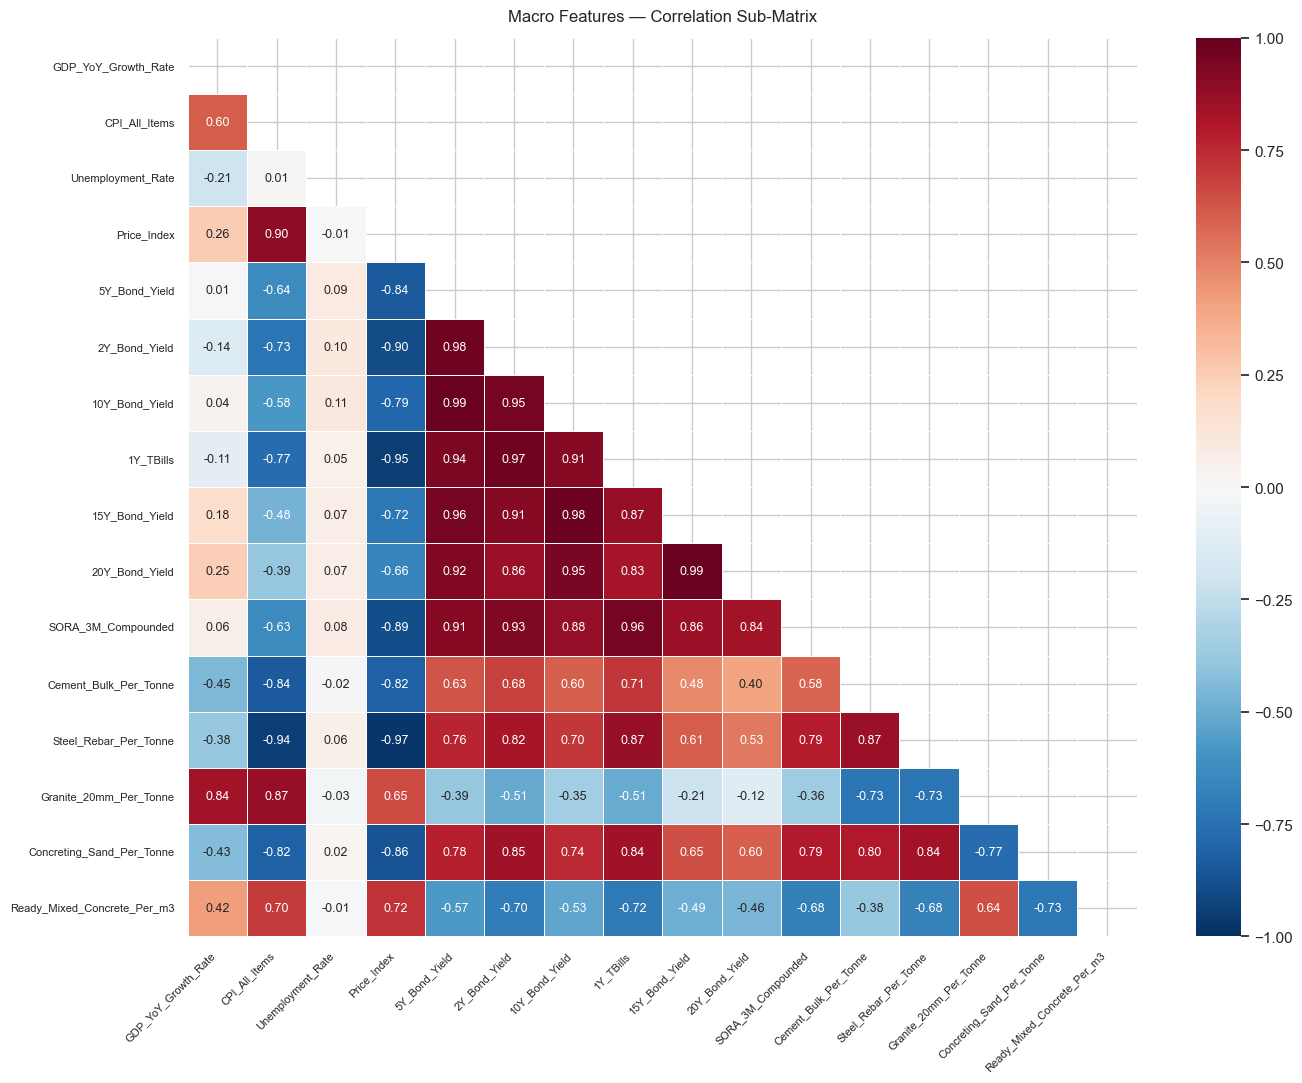

Within-group VIF (macro features only):


,Feature,VIF,Flag
0,15Y_Bond_Yield,719.170000,HIGH
1,10Y_Bond_Yield,326.250000,HIGH
2,5Y_Bond_Yield,294.980000,HIGH
3,20Y_Bond_Yield,256.730000,HIGH
4,2Y_Bond_Yield,225.870000,HIGH
5,Price_Index,117.960000,HIGH
6,1Y_TBills,93.480000,HIGH
7,CPI_All_Items,91.760000,HIGH
8,Steel_Rebar_Per_Tonne,83.880000,HIGH
9,SORA_3M_Compounded,62.710000,HIGH



Macro features — correlation with target:
  +0.060  GDP_YoY_Growth_Rate
  +0.103  CPI_All_Items
  -0.002  Unemployment_Rate
  +0.099  Price_Index
  -0.070  5Y_Bond_Yield
  -0.085  2Y_Bond_Yield
  -0.063  10Y_Bond_Yield
  -0.093  1Y_TBills
  -0.056  15Y_Bond_Yield
  -0.050  20Y_Bond_Yield
  -0.080  SORA_3M_Compounded
  -0.072  Cement_Bulk_Per_Tonne
  -0.100  Steel_Rebar_Per_Tonne
  +0.088  Granite_20mm_Per_Tonne
  -0.092  Concreting_Sand_Per_Tonne
  +0.104  Ready_Mixed_Concrete_Per_m3


In [7]:
macro_cols = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate", "Price_Index",
    "5Y_Bond_Yield", "2Y_Bond_Yield", "10Y_Bond_Yield", "1Y_TBills",
    "15Y_Bond_Yield", "20Y_Bond_Yield", "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne", "Ready_Mixed_Concrete_Per_m3",
]

macro_corr = df[macro_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(macro_corr, dtype=bool))
sns.heatmap(macro_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Macro Features — Correlation Sub-Matrix", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Within-group VIF
print("Within-group VIF (macro features only):")
vif_macro = compute_vif(df[macro_cols].dropna()) 
# display(compute_vif(df[macro_cols].dropna()))
# print(f"VIF Analysis — {len(FEATURE_COLS)} features")
display(vif_macro.style.apply(highlight_vif, axis=1))

# Correlation with target
print("\nMacro features — correlation with target:")
for col in macro_cols:
    r = df[col].corr(df[TARGET])
    print(f"  {r:+.3f}  {col}")

### 5d. Time Features — Excluded from Analysis

`Year`, `Month`, and `Quarter` are **not included as model features**  
They serve solely as mapping keys to join macro indicators (GDP, CPI, SORA, etc.) onto transaction records. Including them would introduce artificial collinearity with the macro features they were used to derive.

### 5e. Construction Materials — Sub-Group Analysis

The 5 construction material features split into two sub-groups with **opposing** target correlations,
but all have weak overall signal (|r| < 0.11). Cross-group correlations are moderate (−0.37 to −0.77),
not high enough to treat them as fully independent groups.

| Sub-group | Features | Target corr | Decision |
|-----------|----------|-------------|----------|
| A — Raw Input Costs | `Cement`, `Steel_Rebar`, `Concreting_Sand` | −0.07 to −0.10 | Drop all |
| B — Construction Activity | `Granite`, `Ready_Mixed_Concrete` | +0.09 to +0.10 | Keep `Ready_Mixed_Concrete_Per_m3` as single proxy |

**Rationale**: `Ready_Mixed_Concrete_Per_m3` is the broadest composite construction cost indicator
(incorporates cement, aggregates, and labour). Keeping a single proxy avoids cross-group collinearity
and simplifies the model without meaningful loss of signal.

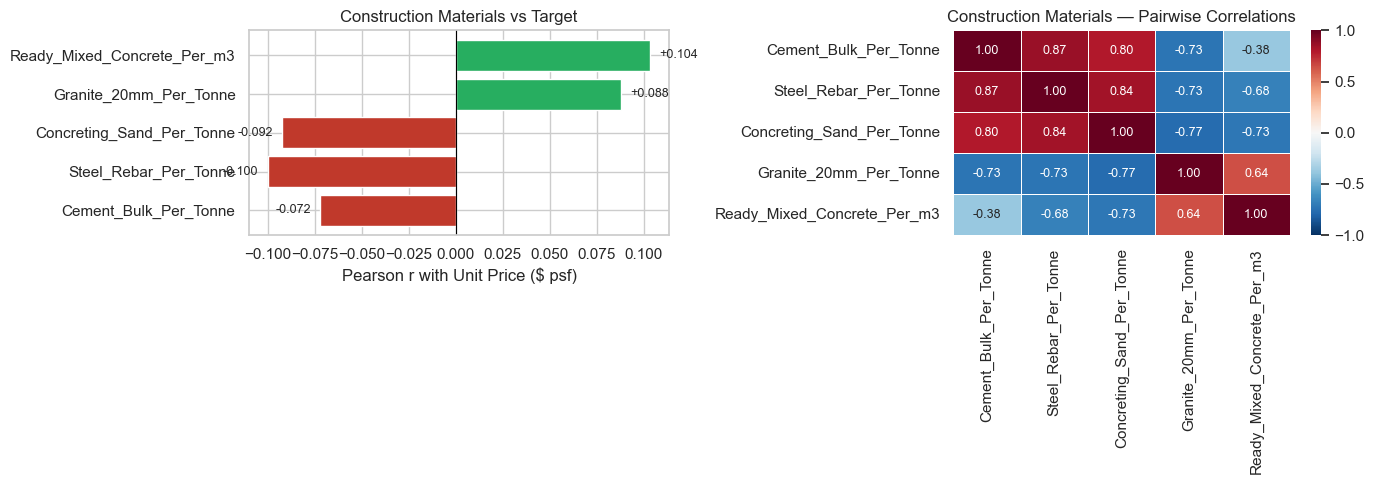

Sub-group A (raw input costs — negative target corr):
  -0.072  Cement_Bulk_Per_Tonne
  -0.100  Steel_Rebar_Per_Tonne
  -0.092  Concreting_Sand_Per_Tonne

Sub-group B (construction activity — positive target corr):
  +0.088  Granite_20mm_Per_Tonne
  +0.104  Ready_Mixed_Concrete_Per_m3

Within-group correlations (Sub-group A):
  Cement_Bulk_Per_Tonne vs Steel_Rebar_Per_Tonne: r = +0.865
  Cement_Bulk_Per_Tonne vs Concreting_Sand_Per_Tonne: r = +0.801
  Steel_Rebar_Per_Tonne vs Concreting_Sand_Per_Tonne: r = +0.839

Recommendation: Keep one from each sub-group.
  Decision: keep Ready_Mixed_Concrete_Per_m3 as a single construction cost proxy.
  Cross-group correlations are moderate (r = -0.37 to -0.77), not sufficient to justify
  two separate representatives. All 5 features have weak target signal (|r| < 0.11).


In [8]:
construction_a = ['Cement_Bulk_Per_Tonne', 'Steel_Rebar_Per_Tonne', 'Concreting_Sand_Per_Tonne']
construction_b = ['Granite_20mm_Per_Tonne', 'Ready_Mixed_Concrete_Per_m3']
all_construction = construction_a + construction_b

# --- Target correlations ---
target_corrs = {f: df[f].corr(df[TARGET]) for f in all_construction}
colors = ['#c0392b' if f in construction_a else '#27ae60' for f in all_construction]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: target correlations
bars = axes[0].barh(list(target_corrs.keys()), list(target_corrs.values()), color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson r with Unit Price ($ psf)')
axes[0].set_title('Construction Materials vs Target')
for bar, val in zip(bars, target_corrs.values()):
    axes[0].text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
                 f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Heatmap: within-group correlations
const_corr = df[all_construction].corr()
sns.heatmap(const_corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', annot_kws={'size': 9}, ax=axes[1])
axes[1].set_title('Construction Materials — Pairwise Correlations')
plt.tight_layout()
plt.show()

# Print summary
print('Sub-group A (raw input costs — negative target corr):')
for f in construction_a:
    print(f'  {target_corrs[f]:+.3f}  {f}')
print('\nSub-group B (construction activity — positive target corr):')
for f in construction_b:
    print(f'  {target_corrs[f]:+.3f}  {f}')
print('\nWithin-group correlations (Sub-group A):')
for i, a in enumerate(construction_a):
    for b in construction_a[i+1:]:
        print(f'  {a} vs {b}: r = {df[a].corr(df[b]):+.3f}')
print('\nRecommendation: Keep one from each sub-group.')
print('  Decision: keep Ready_Mixed_Concrete_Per_m3 as a single construction cost proxy.')
print('  Cross-group correlations are moderate (r = -0.37 to -0.77), not sufficient to justify')
print('  two separate representatives. All 5 features have weak target signal (|r| < 0.11).')


## 6. Feature Selection — Domain-Knowledge Driven

Rather than blindly removing the highest-VIF feature at each step, we select one representative per collinear group based on domain relevance and target correlation. VIF is then run once to confirm the final set is clean.

| Group | Features | Decision | Rationale |
|-------|----------|----------|-----------|
| Lease | `Lease_Duration`, `Remaining_Lease_Years` | Keep `Remaining_Lease_Years` | Higher target correlation (r=+0.674 vs +0.585) |
| Interest Rates | 5Y, 2Y, 10Y, 1Y_TBills, 15Y, 20Y Bond Yields, SORA | Keep `SORA_3M_Compounded` | Singapore lending benchmark — most directly relevant to property |
| Price Level | `Price_Index`, `CPI_All_Items`, `GDP_YoY_Growth_Rate`, `Unemployment_Rate` | Keep `CPI_All_Items` + `GDP_YoY_Growth_Rate` | Drop `Price_Index` (data leakage), drop `Unemployment_Rate` (r~0, only 5 unique values) |
| Construction | `Cement`, `Steel_Rebar`, `Concreting_Sand`, `Granite`, `Ready_Mixed_Concrete` | Keep `Ready_Mixed_Concrete_Per_m3` | Broadest construction cost proxy; all 5 features have weak target signal (|r| < 0.11); cross-group correlations moderate, not sufficient to justify two representatives |


In [9]:
# Domain-selected feature set
SELECTED_FEATURES = [
    "Area (sqft)",                  # Property size
    "Remaining_Lease_Years",        # Primary pricing driver (r=+0.674)
    "SORA_3M_Compounded",           # Interest rate environment — SG lending benchmark
    "CPI_All_Items",                # General inflation
    "GDP_YoY_Growth_Rate",          # Economic growth
    "Ready_Mixed_Concrete_Per_m3",  # Construction cost proxy (r=+0.104)
]

# Confirm VIF is clean for the selected set
vif_final = compute_vif(df[SELECTED_FEATURES].dropna())

print(f"=== VIF Check — {len(SELECTED_FEATURES)} Selected Features ===")
display(vif_final.style.apply(highlight_vif, axis=1))

print("\nTarget correlations:")
for f in SELECTED_FEATURES:
    r = df[f].corr(df[TARGET])
    print(f"  {r:+.3f}  {f}")


=== VIF Check — 6 Selected Features ===


,Feature,VIF,Flag
0,CPI_All_Items,5.310000,WATCH
1,SORA_3M_Compounded,5.260000,WATCH
2,GDP_YoY_Growth_Rate,4.040000,OK
3,Ready_Mixed_Concrete_Per_m3,3.090000,OK
4,Remaining_Lease_Years,1.040000,OK
5,Area (sqft),1.030000,OK



Target correlations:
  -0.353  Area (sqft)
  +0.674  Remaining_Lease_Years
  -0.080  SORA_3M_Compounded
  +0.103  CPI_All_Items
  +0.060  GDP_YoY_Growth_Rate
  +0.104  Ready_Mixed_Concrete_Per_m3


## 7. Summary & Recommendations

In [10]:
print('=' * 60)
print('MULTICOLLINEARITY ANALYSIS - SUMMARY')
print('=' * 60)

dropped = [f for f in FEATURE_COLS if f not in SELECTED_FEATURES]

print(f'\n[DROPPED] {len(dropped)} features removed by group:')
domain_reasons = {
    'Lease_Duration':            'Lease pair      -> Remaining_Lease_Years has stronger target corr (r=+0.674)',
    'Price_Index':               'Price level     -> data leakage (derived from same industrial property market)',
    '5Y_Bond_Yield':             'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    '2Y_Bond_Yield':             'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    '10Y_Bond_Yield':            'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    '1Y_TBills':                 'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    '15Y_Bond_Yield':            'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    '20Y_Bond_Yield':            'Interest rates  -> SORA_3M_Compounded is the SG lending benchmark',
    'Unemployment_Rate':         'Macro           -> weak target corr; GDP and CPI capture macro conditions',
    'Cement_Bulk_Per_Tonne':     'Construction    -> Ready_Mixed_Concrete kept as single construction cost proxy',
    'Steel_Rebar_Per_Tonne':     'Construction    -> Ready_Mixed_Concrete kept as single construction cost proxy',
    'Concreting_Sand_Per_Tonne': 'Construction    -> Ready_Mixed_Concrete kept as single construction cost proxy',
    'Granite_20mm_Per_Tonne':    'Construction    -> Ready_Mixed_Concrete kept as single construction cost proxy',
}
for f in dropped:
    reason = domain_reasons.get(f, '')
    print(f'  - {f:<35} {reason}')

print(f'\n[KEPT] {len(SELECTED_FEATURES)} features:')
for f in SELECTED_FEATURES:
    r = df[f].corr(df[TARGET])
    print(f'  {r:+.3f}  {f}')

print('\n[NOTE] Tree-based models (XGBoost) are robust to multicollinearity.')
print('  The reduced feature set primarily benefits the linear regression model')
print('  for interpretability and stable coefficient estimates.')
print('\n[NEXT STEP]')
print('  notebook 04 reads factory_cleaned.csv with the full feature set.')
print('  The linear model uses SELECTED_FEATURES above.')


MULTICOLLINEARITY ANALYSIS - SUMMARY

[DROPPED] 13 features removed by group:
  - Lease_Duration                      Lease pair      -> Remaining_Lease_Years has stronger target corr (r=+0.674)
  - Unemployment_Rate                   Macro           -> weak target corr; GDP and CPI capture macro conditions
  - Price_Index                         Price level     -> data leakage (derived from same industrial property market)
  - 5Y_Bond_Yield                       Interest rates  -> SORA_3M_Compounded is the SG lending benchmark
  - 2Y_Bond_Yield                       Interest rates  -> SORA_3M_Compounded is the SG lending benchmark
  - 10Y_Bond_Yield                      Interest rates  -> SORA_3M_Compounded is the SG lending benchmark
  - 1Y_TBills                           Interest rates  -> SORA_3M_Compounded is the SG lending benchmark
  - 15Y_Bond_Yield                      Interest rates  -> SORA_3M_Compounded is the SG lending benchmark
  - 20Y_Bond_Yield                      In

### Next Step
→ `notebook 04` — Feature engineering on factory_cleaned.csv